In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox

from sklearn.preprocessing import StandardScaler,MinMaxScaler
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

from sklearn.preprocessing import PolynomialFeatures
from itertools import combinations

from sklearn.preprocessing import RobustScaler

import xgboost as xgb
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from itertools import product
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge, Lasso, BayesianRidge
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
import joblib
from xgboost import XGBRegressor
from scipy.stats import loguniform, randint, uniform

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras.layers import LeakyReLU

In [3]:

data=pd.read_excel("data - copie.xlsx")
data = data.replace({',': '.'}, regex=True)
data.columns=['p','v','h','t','Ra','Desnity','VED','LED','PED']



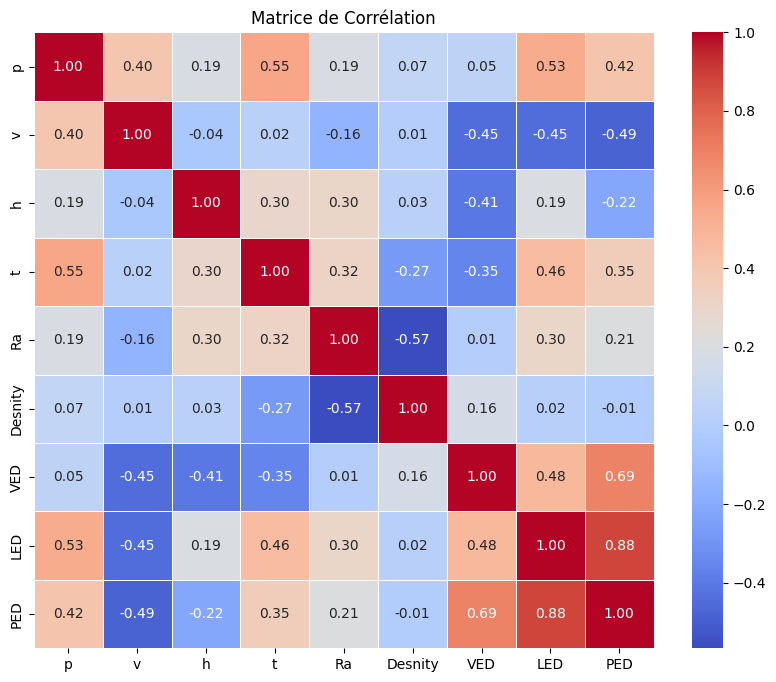

In [30]:
plt.figure(figsize=(10, 8))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Matrice de Corrélation")

plt.show()

In [31]:
data.describe()

,p,v,h,t,Ra,Desnity,VED,LED,PED
count,136.000000,136.000000,136.000000,136.000000,136.000000,86.000000,136.000000,136.000000,136.000000
mean,187.919118,759.191176,95.970588,34.154412,9.952868,96.810000,89.880942,0.267921,2.880364
std,83.143846,247.760690,27.721178,12.642596,5.129858,3.959766,41.872701,0.140037,1.418130
min,60.000000,250.000000,50.000000,20.000000,2.600000,79.530000,17.833333,0.066667,0.937500
25%,150.000000,600.000000,80.000000,25.000000,6.285000,95.645000,60.934388,0.181364,1.860478
50%,160.000000,760.000000,90.000000,30.000000,9.580000,98.375000,81.620370,0.243725,2.492236
75%,225.000000,900.000000,115.000000,40.000000,11.540000,99.320000,108.482143,0.334091,3.612915
max,370.000000,1300.000000,200.000000,60.000000,31.310000,99.930000,227.243916,1.100000,9.166667


In [68]:
data['pv'] = data['p'] * data['v']
data['ph'] = data['p'] * data['h']
data['vh'] = data['v'] * data['h']
data['pt'] = data['p'] * data['t']

data['v_div_h'] = data['v'] / (data['h'] + 1e-5)

data_extended = data.copy()

data_extended['I(p^2)'] = data_extended['p']**2
data_extended['I(v^2)'] = data_extended['v']**2
data_extended['I(h^2)'] = data_extended['h']**2
data_extended['I(t^2)'] = data_extended['t']**2


data_extended['p:v'] = data_extended['p'] * data_extended['v']
data_extended['p:h'] = data_extended['p'] * data_extended['h']
data_extended['p:t'] = data_extended['p'] * data_extended['t']
data_extended['v:h'] = data_extended['v'] * data_extended['h']
data_extended['v:t'] = data_extended['v'] * data_extended['t']
data_extended['h:t'] = data_extended['h'] * data_extended['t']
data_extended['p:v:h'] = data_extended['p'] * data_extended['v'] * data_extended['h']
data_extended['p:v:t'] = data_extended['p'] * data_extended['v'] * data_extended['t']
data_extended['p:h:t'] = data_extended['p'] * data_extended['h'] * data_extended['t']
data_extended['v:h:t'] = data_extended['v'] * data_extended['h'] * data_extended['t']
data_extended['p:v:h:t'] = data_extended['p'] * data_extended['v'] * data_extended['h'] * data_extended['t']

variables = ['p', 'v', 'h', 't']

for var1, var2 in combinations(variables, 2):
    data_extended[f'I({var1}^2 * {var2})'] = (data_extended[var1]**2) * data_extended[var2]

for var1, var2, var3 in combinations(variables, 3):
    data_extended[f'I({var1}^2 * {var2} * {var3}^2)'] = (data_extended[var1]**2) * (data_extended[var2]) * (data_extended[var3]**2)

data_extended[f'I(p^2 * v^2 * h^2 * t^2)'] = (data_extended['p']**2) * (data_extended['v']**2) * (data_extended['h']**2) * (data_extended['t']**2)

data_extended['I(p^2 * v * h)'] = (data_extended['p']**2) * data_extended['v'] * (data_extended['h'])
data_extended['I(p * v^2 * h)'] = data_extended['p'] * (data_extended['v']) * (data_extended['h']**2)
data_extended['I(p^2 * v * h * t)'] = (data_extended['p']**2) * data_extended['v'] * data_extended['h'] * (data_extended['t'])


data_extended['I(sqrt(h)'] = np.sqrt(data_extended['h'])
data_extended['I(sqrt(v)'] = np.sqrt(data_extended['v'])
data_extended['I(sqrt(p)'] = np.sqrt(data_extended['p'])
data_extended['I(sqrt(t)'] = np.sqrt(data_extended['t'])

data_extended['I(sqrt(p) * v)'] = np.sqrt(data_extended['p']) * data_extended['v']
data_extended['I(sqrt(p) * h)'] = np.sqrt(data_extended['p']) * data_extended['h']
data_extended['I(sqrt(p) * t)'] = np.sqrt(data_extended['p']) * data_extended['t']

data_extended['I(sqrt(v) * p)'] = np.sqrt(data_extended['v']) * data_extended['p']
data_extended['I(sqrt(v) * h)'] = np.sqrt(data_extended['v']) * data_extended['h']
data_extended['I(sqrt(v) * t)'] = np.sqrt(data_extended['v']) * data_extended['t']

data_extended['I(sqrt(h) * p)'] = np.sqrt(data_extended['h']) * data_extended['p']
data_extended['I(sqrt(h) * v)'] = np.sqrt(data_extended['h']) * data_extended['v']
data_extended['I(sqrt(h) * t)'] = np.sqrt(data_extended['h']) * data_extended['t']

data_extended['I(sqrt(t) * p)'] = np.sqrt(data_extended['t']) * data_extended['p']
data_extended['I(sqrt(t) * v)'] = np.sqrt(data_extended['t']) * data_extended['v']
data_extended['I(sqrt(t) * h)'] = np.sqrt(data_extended['t']) * data_extended['h']

data_extended['I(p * sqrt(v))'] = data_extended['p'] * np.sqrt(data_extended['v'])
data_extended['I(sqrt(h) * t^2)'] = np.sqrt(data_extended['h']) * (data_extended['t']**2)
data_extended['I(p * h * sqrt(t))'] = data_extended['p'] * data_extended['h'] * np.sqrt(data_extended['t'])

data_extended['I(log(p) * v)'] = np.log(data_extended['p'] + 1e-6) * data_extended['v']
data_extended['I(log(p) * t)'] = np.log(data_extended['p'] + 1e-6) * data_extended['t']
data_extended['I(log(p) * h)'] = np.log(data_extended['p'] + 1e-6) * data_extended['h']
data_extended['I(log(v) * p)'] = np.log(data_extended['v'] + 1e-6) * data_extended['p']
data_extended['I(log(v) * h)'] = np.log(data_extended['v'] + 1e-6) * data_extended['h']
data_extended['I(log(v) * t)'] = np.log(data_extended['v'] + 1e-6) * data_extended['t']
data_extended['I(log(h) * p)'] = np.log(data_extended['h'] + 1e-6) * data_extended['p']
data_extended['I(log(h) * v)'] = np.log(data_extended['h'] + 1e-6) * data_extended['v']
data_extended['I(log(h) * t)'] = np.log(data_extended['h'] + 1e-6) * data_extended['t']
data_extended['I(log(t) * p)'] = np.log(data_extended['t'] + 1e-6) * data_extended['p']
data_extended['I(log(t) * h)'] = np.log(data_extended['t'] + 1e-6) * data_extended['h']
data_extended['I(log(t) * v)'] = np.log(data_extended['t'] + 1e-6) * data_extended['v']
X_selected=["p","v","h","t","I(p^2)","p:h:t","v:h:t","I(t^2)","I(sqrt(p) * h)","I(h^2)"]

In [61]:
X_selected=["p","v","h","t","I(p^2)",	"I(v * h^-1)",	"I(log(p) * h)",	"I(p * v^-1)",	"I(t^2)",	"I(v^-1)",	"I(p^-1 * h^-1)",	"I(log(h) * v)",	"I(t * h^-1)",	"I(h * p^-1)",	"I(t * p^-1)",	"I(v * t^-1)"]

In [69]:
X = data_extended[X_selected].values
y = data[['Ra']].values


In [70]:
def box_cox_fun(data, lambda_val=0.5):
    return ((data + 1e-5) ** lambda_val - 1) / lambda_val

def inverse_box_cox(data, lambda_val=0.5):
    if lambda_val == 0:
        return np.exp(data)
    else:
        return (data * lambda_val + 1) ** (1 / lambda_val) - 1e-5



In [71]:


scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.20, 
    random_state=42,shuffle=True)
y_train_bc=box_cox_fun(y_train)

XGBoost

In [72]:

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform


param_dist = {
    'max_depth': randint(3, 12),
    'learning_rate': loguniform(1e-4, 0.1),
    'n_estimators': randint(200, 1000),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'gamma': uniform(0, 0.3),
    'min_child_weight': randint(1, 10),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0, 0.5),
    'scale_pos_weight': uniform(1, 2),
    'max_delta_step': randint(1, 10),
    'min_split_loss': uniform(0, 0.3)
}

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_jobs=-1,
    early_stopping_rounds=50, 
    eval_metric='rmse'
)

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=3000,               
    cv=5,                     
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train, y_train_bc,
    test_size=0.15,
    random_state=42
)

random_search.fit(
    X_train_part, y_train_part,
    eval_set=[(X_val, y_val)],
    verbose=False
)

best_model = random_search.best_estimator_
print(best_model)
y_pred = best_model.predict(X_test)
y_pred_original = inverse_box_cox(y_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_original))
mae_xgb = mean_absolute_error(y_test, y_pred_original)
r2_xgb = r2_score(y_test, y_pred_original)

print(f"R2: {r2_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")


Fitting 5 folds for each of 3000 candidates, totalling 15000 fits
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7737264313983349, device=None,
             early_stopping_rounds=50, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.17178718538775137, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.07256411011966406,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=2, max_depth=8, max_leaves=None, min_child_weight=3,
             min_split_loss=0.21775941324794182, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=243,
             n_jobs=-1, ...)
R2: 0.5618
RMSE: 2.7242
MAE: 1.9509


In [75]:
joblib.dump(best_model, 'models/xgb_best_model.joblib')

['models/xgb_best_model.joblib']

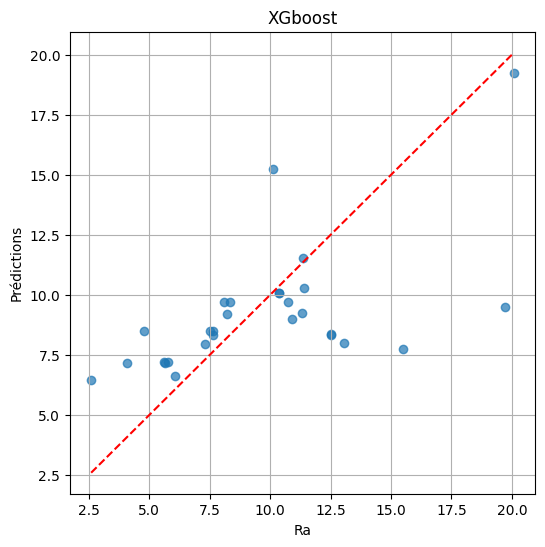

In [14]:
errors = y_test - y_pred_original
abs_errors = np.abs(errors)
percentage_errors = abs_errors / (y_test + 1e-5) * 100


plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_original, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Ra")
plt.ylabel("Prédictions")
plt.title("XGboost")
plt.grid()
plt.show()


RF

In [73]:

from sklearn.ensemble import RandomForestRegressor
import optuna


def objective(trial):
   
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 5, 30, step=1),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20, step=1),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10, step=1),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False])
    }
    
    
    rf = RandomForestRegressor(**params)
    rf.fit(X_train, y_train_bc.ravel())
    
    y_pred_bc_rf = rf.predict(X_test)
    y_pred_rf = inverse_box_cox(y_pred_bc_rf)
    
    
    rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    
    
    return rmse_rf


study = optuna.create_study(direction="minimize")  
study.optimize(objective, n_trials=100)  


print("Best trial:")
print(study.best_trial)
print("Best params:")
print(study.best_params)


[I 2025-05-06 14:34:37,513] A new study created in memory with name: no-name-11789452-6b1c-4825-a9d2-8256c5f578d4
[I 2025-05-06 14:34:38,011] Trial 0 finished with value: 2.402261838409009 and parameters: {'n_estimators': 200, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 2.402261838409009.
[I 2025-05-06 14:34:39,318] Trial 1 finished with value: 2.67702337020191 and parameters: {'n_estimators': 1000, 'max_depth': 14, 'min_samples_split': 15, 'min_samples_leaf': 5, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 2.402261838409009.
[I 2025-05-06 14:34:40,030] Trial 2 finished with value: 2.6572524760747247 and parameters: {'n_estimators': 900, 'max_depth': 27, 'min_samples_split': 7, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 2.402261838409009.
[I 2025-05-06 14:34:40,734] Trial 3 finished with value: 2.901707615607777 and para

Best trial:
FrozenTrial(number=79, state=TrialState.COMPLETE, values=[2.057609366843184], datetime_start=datetime.datetime(2025, 5, 6, 14, 35, 29, 482776), datetime_complete=datetime.datetime(2025, 5, 6, 14, 35, 29, 968986), params={'n_estimators': 400, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=100), 'max_depth': IntDistribution(high=30, log=False, low=5, step=1), 'min_samples_split': IntDistribution(high=20, log=False, low=2, step=1), 'min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1), 'max_features': CategoricalDistribution(choices=('sqrt', 'log2', None)), 'bootstrap': CategoricalDistribution(choices=(True, False))}, trial_id=79, value=None)
Best params:
{'n_estimators': 400, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 

In [74]:

rf = RandomForestRegressor(bootstrap= True, max_depth= 14, max_features='sqrt', min_samples_leaf= 3, min_samples_split= 2, n_estimators= 400)

rf.fit(X_train, y_train_bc.ravel())
y_pred_bc_rf = rf.predict(X_test)
y_pred_rf = inverse_box_cox(y_pred_bc_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
print(f"R2: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"mape: {mape_rf:.4f}")


R2: 0.7265
RMSE: 2.1523
MAE: 1.6957
mape: 52.2062


In [76]:
joblib.dump(rf, 'models/rf.joblib')

['models/rf.joblib']

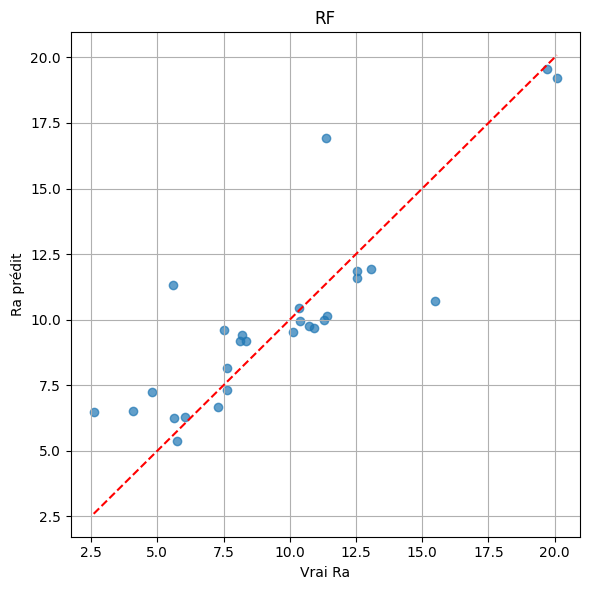

In [42]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Vrai Ra")
plt.ylabel("Ra prédit")
plt.title("RF")
plt.grid(True)
plt.tight_layout()
plt.show()

Neural Network

In [81]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, PReLU
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, AdamW
from tensorflow.keras.callbacks import EarlyStopping



y_test_bc = box_cox_fun(y_test)


def get_optimizer(optimizer_name, learning_rate):
    optimizers_dict = {
        'adam': Adam(learning_rate=learning_rate),
        'adamw': AdamW(learning_rate=learning_rate, weight_decay=1e-4),
        'sgd': SGD(learning_rate=learning_rate),
        'rmsprop': RMSprop(learning_rate=learning_rate),
    }
    
    if optimizer_name.lower() not in optimizers_dict:
        raise ValueError(f"Optimiseur '{optimizer_name}' non supporté ! Choisis parmi {list(optimizers_dict.keys())}")
    
    return optimizers_dict[optimizer_name.lower()]

def build_model(input_dim, optimizer_name, learning_rate):
    opt = get_optimizer(optimizer_name, learning_rate)
    
    model = Sequential([
        Dense(512, input_dim=input_dim),
        BatchNormalization(),
        PReLU(),

        Dense(256),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(128),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(64),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(32),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(16),
        BatchNormalization(),
        PReLU(),
        Dropout(0.2),

        Dense(1, activation='linear')
    ])
    
    model.compile(optimizer=opt, loss=tf.keras.losses.Huber(delta=1.0), metrics=['mae'])
    return model


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=70,
    restore_best_weights=True
)


optimizers = ['adam', 'adamw', 'rmsprop']
learning_rates = [0.001, 0.005, 0.01]
batch_sizes = [16,32]


best_score = float('inf')
best_params = {}
best_model = None
results = []


for opt_name in optimizers:
    for lr in learning_rates:
        for bs in batch_sizes:
            print(f"\n🔵 Test: optimizer={opt_name}, learning_rate={lr}, batch_size={bs}")
            
            model = build_model(X_train.shape[1], opt_name, lr)
            
            history = model.fit(
                X_train, y_train_bc,
                epochs=5000,
                batch_size=bs,
                validation_data=(X_test, y_test_bc),
                verbose=0,
                callbacks=[early_stopping]
            )
            
            preds = model.predict(X_test).squeeze()
            preds = inverse_box_cox(preds)
            
            rmse = np.sqrt(mean_squared_error(y_test, preds))
            mae = mean_absolute_error(y_test, preds)
            r2 = r2_score(y_test, preds)
            
           
            results.append({
                'optimizer': opt_name,
                'learning_rate': lr,
                'batch_size': bs,
                'RMSE': rmse,
                'MAE': mae,
                'R2': r2
            })
            
           
            if rmse < best_score:
                best_score = rmse
                best_params = {'optimizer': opt_name, 'learning_rate': lr, 'batch_size': bs}
                best_model = model


results_df = pd.DataFrame(results)
print("\n📊 Résumé de tous les tests :")
print(results_df.sort_values('RMSE'))


print("\n✅ Meilleurs hyperparamètres trouvés :")
print(best_params)
print(f"RMSE: {best_score:.4f}")


y_pred_final = best_model.predict(X_test)
y_pred_final = inverse_box_cox(y_pred_final)

print("\n📈 Résultats finaux sur le test set :")
print(f"R2 : {r2_score(y_test, y_pred_final):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_final):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_final)):.4f}")




🔵 Test: optimizer=adam, learning_rate=0.001, batch_size=16
1/1 [==============================] - 0s 251ms/step

🔵 Test: optimizer=adam, learning_rate=0.001, batch_size=32
1/1 [==============================] - 0s 210ms/step

🔵 Test: optimizer=adam, learning_rate=0.005, batch_size=16
1/1 [==============================] - 0s 182ms/step

🔵 Test: optimizer=adam, learning_rate=0.005, batch_size=32
1/1 [==============================] - 0s 181ms/step

🔵 Test: optimizer=adam, learning_rate=0.01, batch_size=16
1/1 [==============================] - 0s 190ms/step

🔵 Test: optimizer=adam, learning_rate=0.01, batch_size=32
1/1 [==============================] - 0s 208ms/step

🔵 Test: optimizer=adamw, learning_rate=0.001, batch_size=16
1/1 [==============================] - 0s 232ms/step

🔵 Test: optimizer=adamw, learning_rate=0.001, batch_size=32
1/1 [==============================] - 0s 198ms/step

🔵 Test: optimizer=adamw, learning_rate=0.005, batch_size=16
1/1 [==============================

In [83]:

best_model.save("models/best_keras_model.h5")

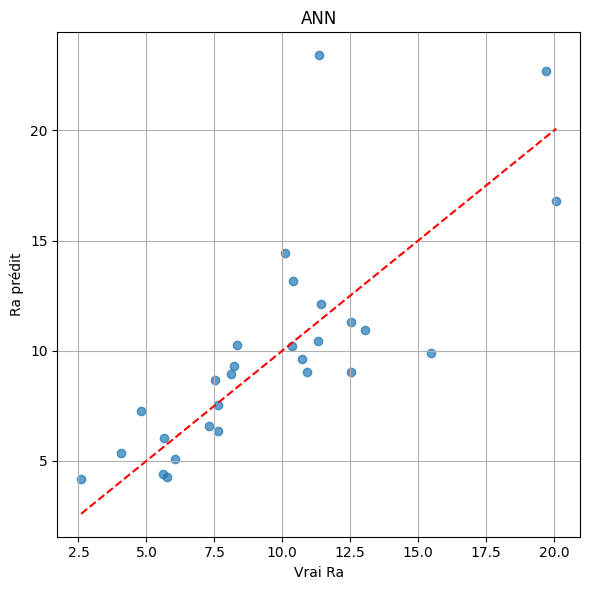

In [80]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_predict, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Vrai Ra")
plt.ylabel("Ra prédit")
plt.title("ANN")
plt.grid(True)
plt.tight_layout()
plt.show()

Catboost

In [77]:

from catboost import CatBoostRegressor


def objective(trial):
    
    params = {
        'iterations': trial.suggest_int('iterations', 1000, 5000, step=500),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-5, 0.1),
        'depth': trial.suggest_int('depth', 4, 12),
        'loss_function': 'RMSE',
        'verbose': 0
    }
    
    
    cat_model = CatBoostRegressor(**params)
    cat_model.fit(X_train, y_train_bc)
    
    
    y_pred_cat_bc = cat_model.predict(X_test)
    y_pred_cat = inverse_box_cox(y_pred_cat_bc)
    
    
    rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
    
    
    return rmse_cat


study = optuna.create_study(direction="minimize")  
study.optimize(objective, n_trials=50)  

print("Best trial:")
print(study.best_trial)
print("Best params:")
print(study.best_params)


[I 2025-05-06 14:37:57,721] A new study created in memory with name: no-name-2d5c5f4e-fbea-4587-a2cd-00ba10fb48c7
C:\Users\hrouabah\AppData\Local\Temp\ipykernel_18608\3198540404.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-5, 0.1),
[I 2025-05-06 14:38:04,369] Trial 0 finished with value: 1.7293661622220873 and parameters: {'iterations': 5000, 'learning_rate': 0.002995293206351453, 'depth': 8}. Best is trial 0 with value: 1.7293661622220873.
C:\Users\hrouabah\AppData\Local\Temp\ipykernel_18608\3198540404.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learn

KeyboardInterrupt: 

In [78]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.06999743684066881,
    depth=9,
    loss_function='RMSE',
    verbose=1,
   
)
cat_model.fit(X_train, y_train_bc)

y_pred_cat_bc = cat_model.predict(X_test)
y_pred_cat=inverse_box_cox(y_pred_cat_bc)

r2_cat = r2_score(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
mae_cat = mean_absolute_error(y_test, y_pred_cat)
mape_cat = np.mean(np.abs((y_test - y_pred_cat) / y_test)) * 100
print(f"R2: {r2_cat:.4f}")
print(f"RMSE: {rmse_cat:.4f}")
print(f"MAE: {mae_cat:.4f}")
print(f"MAPE: {mape_cat:.4f}")

0:	learn: 1.4896917	total: 6.68ms	remaining: 20s
1:	learn: 1.4615864	total: 9.49ms	remaining: 14.2s
2:	learn: 1.4290351	total: 12ms	remaining: 12s
3:	learn: 1.4103513	total: 15.6ms	remaining: 11.7s
4:	learn: 1.3842994	total: 17.3ms	remaining: 10.4s
5:	learn: 1.3627766	total: 22.7ms	remaining: 11.3s
6:	learn: 1.3455876	total: 25.5ms	remaining: 10.9s
7:	learn: 1.3240340	total: 29ms	remaining: 10.8s
8:	learn: 1.3022809	total: 33.4ms	remaining: 11.1s
9:	learn: 1.2804065	total: 36.7ms	remaining: 11s
10:	learn: 1.2616699	total: 39.6ms	remaining: 10.8s
11:	learn: 1.2490216	total: 40.2ms	remaining: 10s
12:	learn: 1.2298751	total: 42.1ms	remaining: 9.67s
13:	learn: 1.2193194	total: 42.9ms	remaining: 9.16s
14:	learn: 1.2051152	total: 44.9ms	remaining: 8.94s
15:	learn: 1.1893481	total: 48.6ms	remaining: 9.07s
16:	learn: 1.1689206	total: 52.4ms	remaining: 9.19s
17:	learn: 1.1460617	total: 55.2ms	remaining: 9.14s
18:	learn: 1.1348873	total: 56.5ms	remaining: 8.86s
19:	learn: 1.1188970	total: 61.8ms

In [82]:
joblib.dump(cat_model, 'models/cat_model.joblib')

['models/cat_model.joblib']

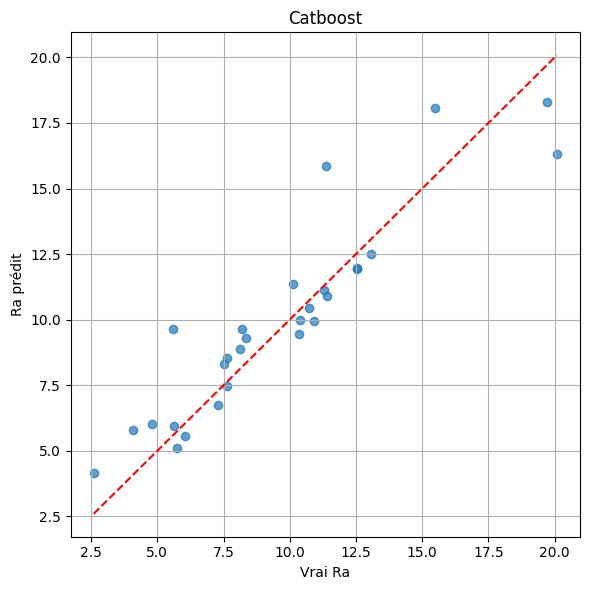

In [80]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_cat, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Vrai Ra")
plt.ylabel("Ra prédit")
plt.title("Catboost")
plt.grid(True)
plt.tight_layout()
plt.show()

SVM

Fitting 5 folds for each of 1350 candidates, totalling 6750 fits

--- Meilleur SVR trouvé ---
Best params: {'C': 10, 'degree': 2, 'epsilon': 0.1, 'gamma': 1, 'kernel': 'rbf'}
R2: 0.6422
RMSE: 2.4614
MAE: 1.6216
MAPE: 52.32%


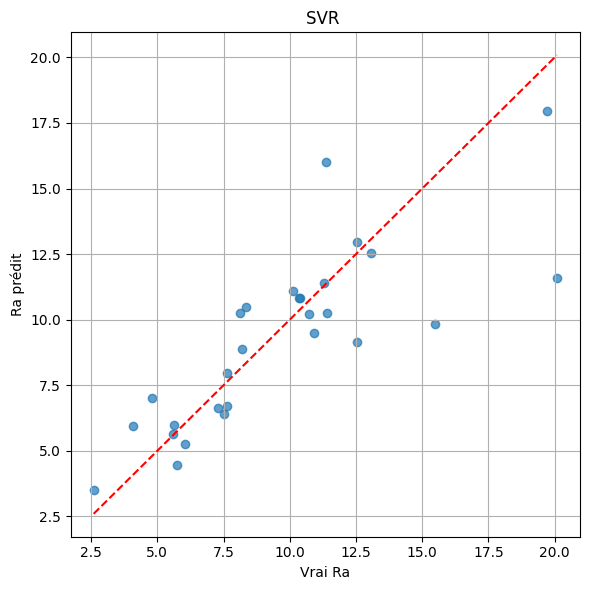

In [46]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_grid_svr = {
    'C': [0.1, 1, 10, 100, 1000],
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
    'kernel': ['rbf', 'poly', 'sigmoid'],
    'degree': [2, 3, 4],  
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

svr = SVR()
grid_svr = GridSearchCV(
    svr,
    param_grid=param_grid_svr,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=-1
)

grid_svr.fit(X_train, y_train_bc.ravel())
best_svr = grid_svr.best_estimator_


y_pred_bc_svr = best_svr.predict(X_test)
y_pred_svr = inverse_box_cox(y_pred_bc_svr)


rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)
mape_svr = np.mean(np.abs((y_test - y_pred_svr) / y_test)) * 100

print("\n--- Meilleur SVR trouvé ---")
print(f"Best params: {grid_svr.best_params_}")
print(f"R2: {r2_svr:.4f}")
print(f"RMSE: {rmse_svr:.4f}")
print(f"MAE: {mae_svr:.4f}")
print(f"MAPE: {mape_svr:.2f}%")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_svr, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Vrai Ra")
plt.ylabel("Ra prédit")
plt.title("SVR ")
plt.grid(True)
plt.tight_layout()
plt.show()


In [47]:
joblib.dump(best_svr, 'models/best_svr.joblib')

['models/best_svr.joblib']

DTR


--- Decision Tree ---
R2: 0.6265
RMSE: 2.5151
MAE: 1.7100
MAPE: 58.99%


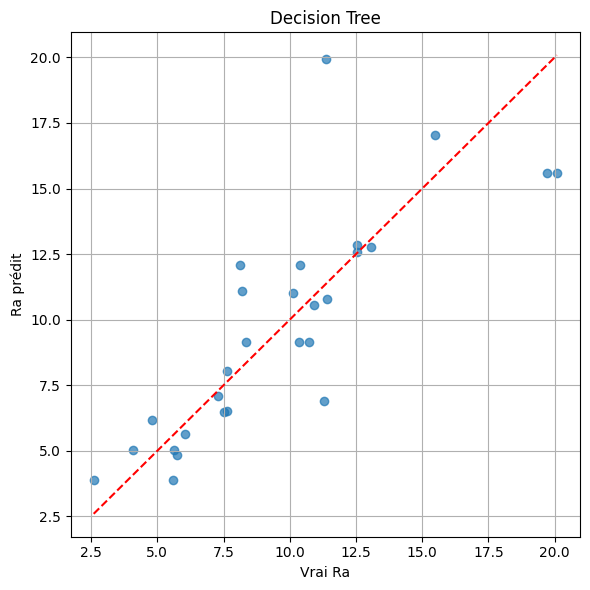

In [48]:
from sklearn.tree import DecisionTreeRegressor


tree = DecisionTreeRegressor(max_depth=15, min_samples_split=4, min_samples_leaf=2, random_state=42)

tree.fit(X_train, y_train_bc.ravel())
y_pred_bc_tree = tree.predict(X_test)
y_pred_tree = inverse_box_cox(y_pred_bc_tree)


rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
mape_tree = np.mean(np.abs((y_test - y_pred_tree) / y_test)) * 100

print("\n--- Decision Tree ---")
print(f"R2: {r2_tree:.4f}")
print(f"RMSE: {rmse_tree:.4f}")
print(f"MAE: {mae_tree:.4f}")
print(f"MAPE: {mape_tree:.2f}%")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_tree, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Vrai Ra")
plt.ylabel("Ra prédit")
plt.title("Decision Tree")
plt.grid(True)
plt.tight_layout()
plt.show()


In [49]:
joblib.dump(tree, 'models/tree.joblib')

['models/tree.joblib']

Bayesien Ridge


--- Bayesian Ridge ---
R2: 0.2712
RMSE: 3.5131
MAE: 2.8450
MAPE: 45.36%


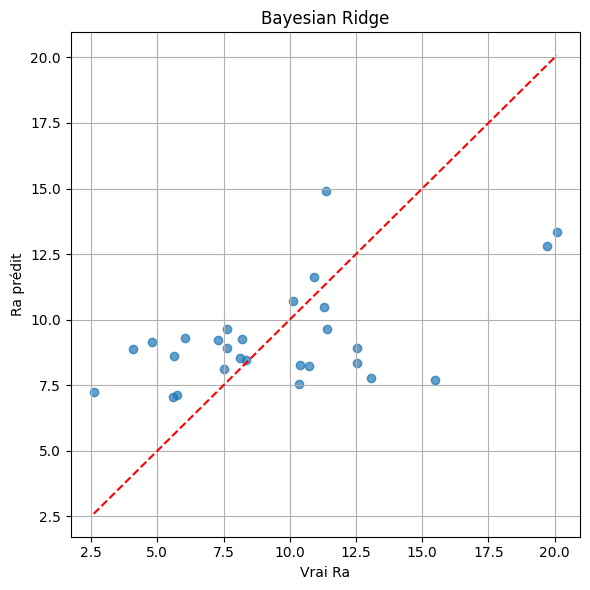

In [51]:
from sklearn.linear_model import BayesianRidge


bayes = BayesianRidge(alpha_1=1e-6, alpha_2=1e-6, lambda_1=1e-6, lambda_2=1e-6)

bayes.fit(X_train, y_train_bc.ravel())
y_pred_bc_bayes = bayes.predict(X_test)
y_pred_bayes = inverse_box_cox(y_pred_bc_bayes)


rmse_bayes = np.sqrt(mean_squared_error(y_test, y_pred_bayes))
mae_bayes = mean_absolute_error(y_test, y_pred_bayes)
r2_bayes = r2_score(y_test, y_pred_bayes)
mape_bayes = np.mean(np.abs((y_test - y_pred_bayes) / y_test)) * 100

print("\n--- Bayesian Ridge ---")
print(f"R2: {r2_bayes:.4f}")
print(f"RMSE: {rmse_bayes:.4f}")
print(f"MAE: {mae_bayes:.4f}")
print(f"MAPE: {mape_bayes:.2f}%")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_bayes, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Vrai Ra")
plt.ylabel("Ra prédit")
plt.title("Bayesian Ridge")
plt.grid(True)
plt.tight_layout()
plt.show()


In [56]:
joblib.dump(bayes, 'models/bayes.joblib')

['models/bayes.joblib']

TABNET

In [84]:

from pytorch_tabnet.tab_model import TabNetRegressor
import torch





def objective(trial):
    params = {
        'n_d': trial.suggest_categorical('n_d', [32, 64, 128, 256]),
        'n_a': trial.suggest_categorical('n_a', [32, 64, 128, 256]),
        'n_steps': trial.suggest_int('n_steps', 3, 10),
        'gamma': trial.suggest_float('gamma', 1.0, 2.0),
        'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-7, 1e-3, log=True),
        'optimizer_fn': torch.optim.Adam,
        'optimizer_params': dict(lr=trial.suggest_float('lr', 1e-4, 1e-2, log=True)),
        'mask_type': trial.suggest_categorical('mask_type', ['sparsemax', 'entmax']),
        'scheduler_params': {"step_size":50, "gamma":0.9},
        'scheduler_fn': torch.optim.lr_scheduler.StepLR,
        'verbose': 0,
    }
    
    model = TabNetRegressor(**params)
    
    model.fit(
        X_train=X_train,
        y_train=y_train_bc,
        eval_set=[(X_test, y_test_bc)],
        eval_metric=['rmse'],
        patience=30,
        max_epochs=300,
        batch_size=32,
        virtual_batch_size=16,
        num_workers=0
    )
    
    preds = model.predict(X_test)
    score = np.sqrt(mean_squared_error(y_test_bc, preds)) 
    
    return score 


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50) 


print("Best trial:")
print(study.best_trial)
print("Best params:")
print(study.best_params)


[I 2025-05-06 15:09:07,413] A new study created in memory with name: no-name-21630d3d-5416-42b0-8bc5-3e4abac306d8
c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-05-06 15:09:42,790] Trial 0 finished with value: 1.175896787975931 and parameters: {'n_d': 32, 'n_a': 32, 'n_steps': 4, 'gamma': 1.2495757065552064, 'lambda_sparse': 6.909726928537366e-05, 'lr': 0.0007906261055190136, 'mask_type': 'entmax'}. Best is trial 0 with value: 1.175896787975931.



Early stopping occurred at epoch 109 with best_epoch = 79 and best_val_0_rmse = 1.1759


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-05-06 15:10:23,883] Trial 1 finished with value: 0.9370141557703369 and parameters: {'n_d': 32, 'n_a': 32, 'n_steps': 8, 'gamma': 1.3046336029088494, 'lambda_sparse': 0.00030821301789690184, 'lr': 0.0024865022545434304, 'mask_type': 'sparsemax'}. Best is trial 1 with value: 0.9370141557703369.



Early stopping occurred at epoch 131 with best_epoch = 101 and best_val_0_rmse = 0.93701


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-05-06 15:10:47,411] Trial 2 finished with value: 0.9416668159427112 and parameters: {'n_d': 64, 'n_a': 64, 'n_steps': 6, 'gamma': 1.5742648321707289, 'lambda_sparse': 4.795102511098086e-06, 'lr': 0.005835034227436647, 'mask_type': 'entmax'}. Best is trial 1 with value: 0.9370141557703369.


...


Early stopping occurred at epoch 105 with best_epoch = 75 and best_val_0_rmse = 0.94705


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-05-06 15:31:57,943] Trial 48 finished with value: 0.9284527830670021 and parameters: {'n_d': 32, 'n_a': 256, 'n_steps': 6, 'gamma': 1.0553507352279135, 'lambda_sparse': 0.0001871114293000153, 'lr': 0.0004352471957735031, 'mask_type': 'entmax'}. Best is trial 3 with value: 0.5835605797907194.



Early stopping occurred at epoch 136 with best_epoch = 106 and best_val_0_rmse = 0.92845


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-05-06 15:32:35,758] Trial 49 finished with value: 1.0634883915905258 and parameters: {'n_d': 256, 'n_a': 32, 'n_steps': 7, 'gamma': 1.160446668690179, 'lambda_sparse': 0.0004102865355678414, 'lr': 0.0029193391942867125, 'mask_type': 'entmax'}. Best is trial 3 with value: 0.5835605797907194.



Early stopping occurred at epoch 127 with best_epoch = 97 and best_val_0_rmse = 1.06349
Best trial:
FrozenTrial(number=3, state=TrialState.COMPLETE, values=[0.5835605797907194], datetime_start=datetime.datetime(2025, 5, 6, 15, 10, 47, 413135), datetime_complete=datetime.datetime(2025, 5, 6, 15, 11, 37, 965684), params={'n_d': 256, 'n_a': 128, 'n_steps': 3, 'gamma': 1.2217689715327418, 'lambda_sparse': 0.0005148572857613338, 'lr': 0.006150451067704911, 'mask_type': 'entmax'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_d': CategoricalDistribution(choices=(32, 64, 128, 256)), 'n_a': CategoricalDistribution(choices=(32, 64, 128, 256)), 'n_steps': IntDistribution(high=10, log=False, low=3, step=1), 'gamma': FloatDistribution(high=2.0, log=False, low=1.0, step=None), 'lambda_sparse': FloatDistribution(high=0.001, log=True, low=1e-07, step=None), 'lr': FloatDistribution(high=0.01, log=True, low=0.0001, step=None), 'mask_type': CategoricalDistribution(choices=('

In [85]:
tabnet_model = TabNetRegressor(
    n_d=256,
    n_a=128,
    n_steps=3,
    gamma=1.2217689715327418,
    lambda_sparse=0.0005148572857613338,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.006150451067704911),
    mask_type='entmax'
)


tabnet_model.fit(
    X_train,
    y_train_bc,
    eval_set=[(X_test, y_test_bc)],
    eval_metric=['rmse'],
    patience=30,
    max_epochs=300,
    batch_size=32,
    virtual_batch_size=16,
    num_workers=0
)

y_pred_tabnet_bc = tabnet_model.predict(X_test)
y_pred_tabnet = inverse_box_cox(y_pred_tabnet_bc)


r2_tabnet = r2_score(y_test, y_pred_tabnet)
rmse_tabnet = np.sqrt(mean_squared_error(y_test, y_pred_tabnet))
mae_tabnet = mean_absolute_error(y_test, y_pred_tabnet)
mape_tabnet = np.mean(np.abs((y_test - y_pred_tabnet) / y_test)) * 100

print(f"R2: {r2_tabnet:.4f}")
print(f"RMSE: {rmse_tabnet:.4f}")
print(f"MAE: {mae_tabnet:.4f}")
print(f"MAPE: {mape_tabnet:.4f}")
tabnet_model.save_model('models/tabnet_model.zip')

c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 13.70807| val_0_rmse: 14.09566|  0:00:00s
epoch 1  | loss: 15.98122| val_0_rmse: 7.16163 |  0:00:00s
epoch 2  | loss: 7.29695 | val_0_rmse: 8.49108 |  0:00:00s
epoch 3  | loss: 15.48098| val_0_rmse: 6.93944 |  0:00:00s
epoch 4  | loss: 6.45922 | val_0_rmse: 5.73271 |  0:00:01s
epoch 5  | loss: 7.15189 | val_0_rmse: 4.4595  |  0:00:01s
epoch 6  | loss: 4.16821 | val_0_rmse: 5.10389 |  0:00:01s
epoch 7  | loss: 6.36343 | val_0_rmse: 4.04766 |  0:00:01s
epoch 8  | loss: 6.4578  | val_0_rmse: 4.17714 |  0:00:02s
epoch 9  | loss: 5.55687 | val_0_rmse: 4.03929 |  0:00:02s
epoch 10 | loss: 4.14357 | val_0_rmse: 1.96626 |  0:00:02s
epoch 11 | loss: 4.52401 | val_0_rmse: 2.63196 |  0:00:02s
epoch 12 | loss: 3.10745 | val_0_rmse: 2.17757 |  0:00:03s
epoch 13 | loss: 3.38863 | val_0_rmse: 3.07247 |  0:00:03s
epoch 14 | loss: 5.84858 | val_0_rmse: 1.45197 |  0:00:03s
epoch 15 | loss: 2.72028 | val_0_rmse: 1.59784 |  0:00:03s
epoch 16 | loss: 3.46511 | val_0_rmse: 2.06021 |  0:00:0

c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


R2: 0.6745
RMSE: 2.3478
MAE: 1.7091
MAPE: 18.8341
Successfully saved model at models/tabnet_model.zip.zip


'models/tabnet_model.zip.zip'

Comparaison 

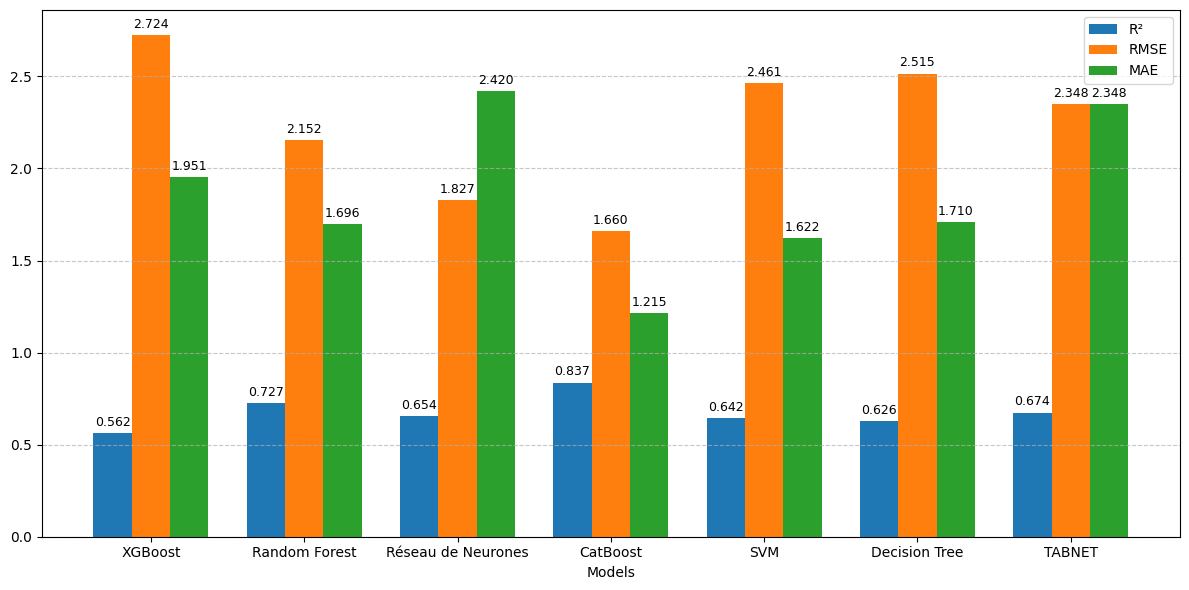

In [6]:
R2_rn =0.6542
MAE_rn = 1.8272
RMSE_rn = 2.4199

r2_xgb= 0.5618
rmse_xgb= 2.7242
mae_xgb= 1.9509

r2_rf= 0.7265
rmse_rf= 2.1523
mae_rf= 1.6957

r2_cat= 0.8373
rmse_cat= 1.6599
mae_cat= 1.2154


r2_tabnet= 0.6745
rmse_tabnet= 2.3478
mae_tabnet= 1.7091

r2_tree= 0.6265
rmse_tree= 2.5151
mae_tree=1.7100

r2_svr= 0.6422
rmse_svr= 2.4614
mae_svr= 1.6216
models = ['XGBoost', 'Random Forest', 'Réseau de Neurones', 'CatBoost', 'SVM', 'Decision Tree', 'TABNET']


r2_scores = [r2_xgb, r2_rf, R2_rn, r2_cat, r2_svr, r2_tree, r2_tabnet]
rmse_scores = [rmse_xgb, rmse_rf, MAE_rn, rmse_cat, rmse_svr, rmse_tree, rmse_tabnet]
mae_scores = [mae_xgb, mae_rf, RMSE_rn, mae_cat, mae_svr, mae_tree, rmse_tabnet]


x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, r2_scores, width, label='R²')
bars2 = ax.bar(x, rmse_scores, width, label='RMSE')
bars3 = ax.bar(x + width, mae_scores, width, label='MAE')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

ax.set_xlabel('Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()


Stacking

In [58]:
from itertools import product, combinations


all_base_models = {
    'cat': cat_model,
    'rf': rf,
    'svm': best_svr,
    'dtr': tree
}


base_combos = []
for r in range(2, len(all_base_models) + 1):
    base_combos.extend(combinations(all_base_models.items(), r))


ridge_alphas = [0.1, 1.0, 10.0]
lasso_alphas = [0.001, 0.01, 0.1]
svr_params = [
    {'kernel': 'rbf', 'C': 0.1, 'epsilon': 0.01},
    {'kernel': 'rbf', 'C': 1.0, 'epsilon': 0.1},
    {'kernel': 'linear', 'C': 0.5, 'epsilon': 0.1},
]

meta_models = {}

for alpha in ridge_alphas:
    meta_models[f"ridge_{alpha}"] = Ridge(alpha=alpha)

for alpha in lasso_alphas:
    meta_models[f"lasso_{alpha}"] = Lasso(alpha=alpha, max_iter=10000)

for params in svr_params:
    meta_models[f"svr_{params['kernel']}_{params['C']}"] = make_pipeline(SVR(**params))

meta_models['bayesian'] = BayesianRidge()


cv_values = [3, 4, 5]
passthrough_values = [True, False]


stacking_results = {}


for base_combo in base_combos:
    base_names = [name for name, _ in base_combo]
    base_learners = list(base_combo)

    for (meta_name, meta_model), cv, passthrough in product(meta_models.items(), cv_values, passthrough_values):
        config_name = f"{'+'.join(base_names)} | meta={meta_name} | CV={cv} | passthrough={passthrough}"
        print(f"\n🚀 Training: {config_name}")

        stack = StackingRegressor(
            estimators=base_learners,
            final_estimator=meta_model,
            passthrough=passthrough,
            cv=cv,
            n_jobs=-1
        )

       
        stack.fit(X_train, y_train_bc.ravel())
        preds = stack.predict(X_test)
        preds = inverse_box_cox(preds)

        
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)

        stacking_results[config_name] = {
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        }

        print(f"✅ Résultats : R2={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")



🚀 Training: cat+rf | meta=ridge_0.1 | CV=3 | passthrough=True
✅ Résultats : R2=0.2457, RMSE=3.5741, MAE=2.3438

🚀 Training: cat+rf | meta=ridge_0.1 | CV=3 | passthrough=False
✅ Résultats : R2=0.7553, RMSE=2.0359, MAE=1.4772

🚀 Training: cat+rf | meta=ridge_0.1 | CV=4 | passthrough=True
✅ Résultats : R2=0.5782, RMSE=2.6725, MAE=1.7172

🚀 Training: cat+rf | meta=ridge_0.1 | CV=4 | passthrough=False
✅ Résultats : R2=0.7378, RMSE=2.1072, MAE=1.3378

🚀 Training: cat+rf | meta=ridge_0.1 | CV=5 | passthrough=True
✅ Résultats : R2=0.4473, RMSE=3.0594, MAE=2.1104

🚀 Training: cat+rf | meta=ridge_0.1 | CV=5 | passthrough=False
✅ Résultats : R2=0.7566, RMSE=2.0300, MAE=1.4411

🚀 Training: cat+rf | meta=ridge_1.0 | CV=3 | passthrough=True
✅ Résultats : R2=0.4614, RMSE=3.0200, MAE=1.9793

🚀 Training: cat+rf | meta=ridge_1.0 | CV=3 | passthrough=False
✅ Résultats : R2=0.7180, RMSE=2.1852, MAE=1.5414

🚀 Training: cat+rf | meta=ridge_1.0 | CV=4 | passthrough=True
✅ Résultats : R2=0.5890, RMSE=2.6383,

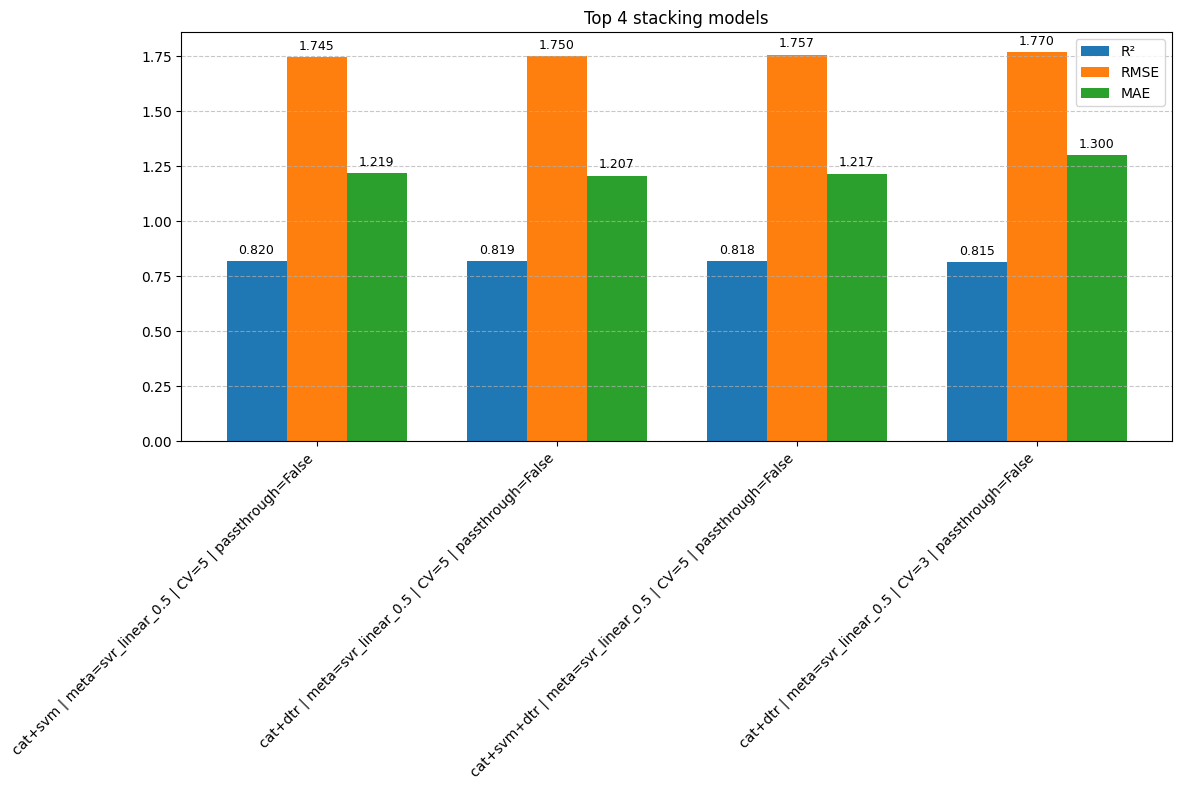

In [59]:
top_4_stacks = sorted(stacking_results.items(), key=lambda x: x[1]['R2'], reverse=True)[:4]
labels = [name for name, _ in top_4_stacks]
r2_scores = [scores['R2'] for _, scores in top_4_stacks]
rmse_scores = [scores['RMSE'] for _, scores in top_4_stacks]
mae_scores = [scores['MAE'] for _, scores in top_4_stacks]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 8))


bars1 = ax.bar(x - width, r2_scores, width, label='R²')
bars2 = ax.bar(x, rmse_scores, width, label='RMSE')
bars3 = ax.bar(x + width, mae_scores, width, label='MAE')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)


ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_title("Top 4 stacking models")
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()